In [1]:
print ("helloworld")

helloworld


In [2]:
print ("linear regression practice")

linear regression practice


In [3]:
import numpy as np

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [5]:
from sklearn.datasets import fetch_california_housing
data=fetch_california_housing()
X=pd.DataFrame(data.data, columns=data.feature_names)
y= data.target

In [6]:
#---2. split

In [7]:
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
scaler=StandardScaler()
X_train_s=scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [9]:
#----4.train
model=LinearRegression()
model.fit(X_train_s, y_train)

LinearRegression()

In [11]:
y_pred=model.predict(X_test_s)
mse =mean_squared_error(y_test, y_pred)
rmse =np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse: .3f}")
print(f"R²:   {r2:.3f}") 

RMSE:  0.746
R²:   0.576


In [12]:
############linear regression execise 1:

execises begin from here .

Intercept (θ₀): 45992.01
Slope     (θ₁): 511.03


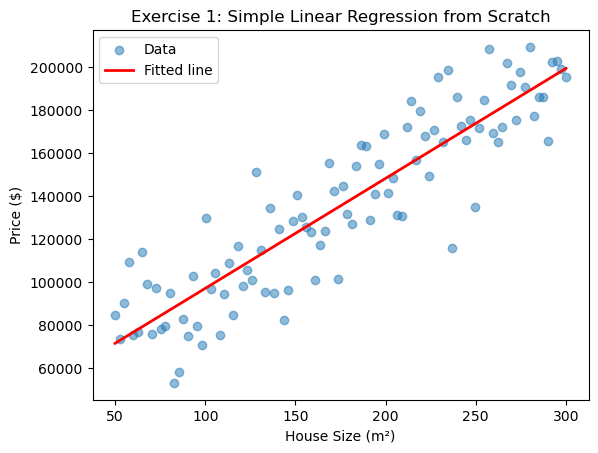

RMSE: $18054


In [39]:

import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate data
np.random.seed(42)
X = np.linspace(50, 300, 100)
y = 500 * X + 50000 + np.random.normal(0, 20000, 100)

# X = (X - np.mean(X)) / np.std(X)
# y = (y - np.mean(y)) / np.std(y)
# Step 2: Add bias column (column of 1s) to X
X_b = np.c_[np.ones(len(X)), X]   # shape: (100, 2)

# Step 3: Normal equation — fill this in!
theta =theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y  # (X_bᵀ X_b)⁻¹ X_bᵀ y

# Step 4: Print parameters
print(f"Intercept (θ₀): {theta[0]:.2f}")
print(f"Slope     (θ₁): {theta[1]:.2f}")

# Step 5: Plot
x_line = np.array([50, 300])
y_line = theta[0] + theta[1] * x_line
plt.scatter(X, y, alpha=0.5, label='Data')
plt.plot(x_line, y_line, 'r-', linewidth=2, label='Fitted line')
plt.xlabel('House Size (m²)')
plt.ylabel('Price ($)')
plt.legend()
plt.title('Exercise 1: Simple Linear Regression from Scratch')
plt.show()

# Step 6: RMSE
y_pred = X_b @ theta
rmse = np.sqrt(np.mean((y - y_pred)**2))
print(f"RMSE: ${rmse:.0f}")

linear regression execise 2

α=0.0001: θ = [12887.82168421  3545.10952558]
α=0.002: θ = [117132.21742129  32220.07177842]
α=0.01: θ = [135417.22326927  37249.80837746]


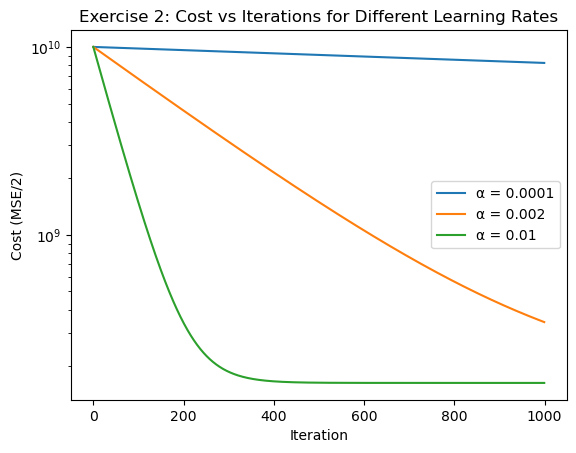

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate data
np.random.seed(42)
X = np.linspace(50, 300, 100)
y = 500 * X + 50000 + np.random.normal(0, 20000, 100)

X = (X - np.mean(X)) / np.std(X)
# y = (y - np.mean(y)) / np.std(y)
# Step 2: Add bias column (column of 1s) to X
X_b = np.c_[np.ones(len(X)), X]   # shape: (100, 2)


def gradient_descent(X_b, y, alpha, n_iterations):
    m=len(y)
    theta = np.zeros(2)
    cost_history=[]
    for iterations in range(n_iterations):
        y_pred=X_b @ theta
        error=y_pred-y
        gradients=(1/m) * X_b.T @ error
        theta=theta - alpha * gradients
        cost= (1/(2*m)) * np.sum(error**2)
        cost_history.append(cost)
    return theta, cost_history
for alpha in [0.0001, 0.002, 0.01]:
    theta_gd, costs=gradient_descent(X_b, y, alpha, n_iterations=1000)
    plt.plot(costs, label=f'α = {alpha}')
    print(f"α={alpha}: θ = {theta_gd}")

plt.xlabel('Iteration')
plt.ylabel('Cost (MSE/2)')
plt.yscale('log')   # log scale makes differences clearer
plt.legend()
plt.title('Exercise 2: Cost vs Iterations for Different Learning Rates')
plt.show()


In [38]:
print("Gradient Descent:", theta_gd)
print("Normal Equation:", theta)


np.allclose(theta_gd, theta, atol=1e-2)

Gradient Descent: [135417.22326927  37249.80837746]
Normal Equation: [135423.06965212  37251.41656758]


False

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [59]:
from sklearn.datasets import fetch_california_housing
dataset=fetch_california_housing()
X=pd.DataFrame(data.data, columns=data.feature_names)
y=data.target

In [60]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y, test_size=0.2,
    random_state=42
)

In [62]:
scaler=StandardScaler()
X_train_s=scaler.fit_transform(X_train)
X_test_s=scaler.transform(X_test)

In [63]:
model=LinearRegression()
model.fit(X_train_s,y_train)

LinearRegression()

In [64]:
y_pred = model.predict(X_test_s)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print(f"RMSE: {rmse:.3f}")        # e.g. RMSE: 0.726
print(f"R²:   {r2:.3f}")          # e.

RMSE: 0.746
R²:   0.576


In [65]:
coef_df = pd.DataFrame({
    'Feature': data.feature_names,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)
print(coef_df)  # positive coef = 

      Feature  Coefficient
0      MedInc     0.854383
3   AveBedrms     0.339259
1    HouseAge     0.122546
4  Population    -0.002308
5    AveOccup    -0.040829
2    AveRooms    -0.294410
7   Longitude    -0.869842
6    Latitude    -0.896929


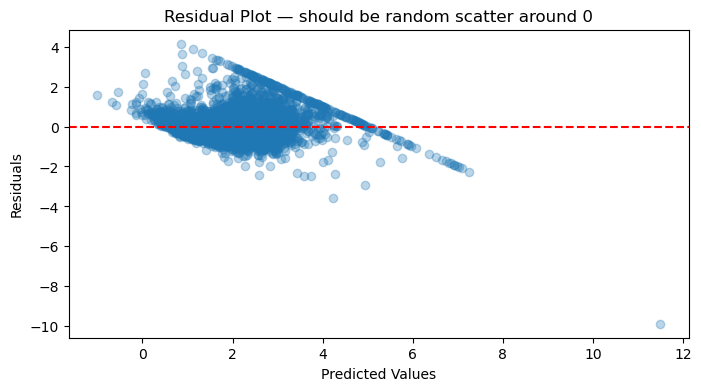

In [66]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot — should be random scatter around 0')
plt.show()